In [1]:
from pathlib import Path
import pandas as pd

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [ ]:
trainer_state_path_ecb = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/Bert Model Finetuning Code /Trail of Different Data Split/Learning rate - 3e-5/logs/ECB-v5/*trainer_state.json")
trainer_state_path_fed = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/Bert Model Finetuning Code /Trail of Different Data Split/Learning rate - 3e-5/logs/FED-v5/*trainer_state.json")


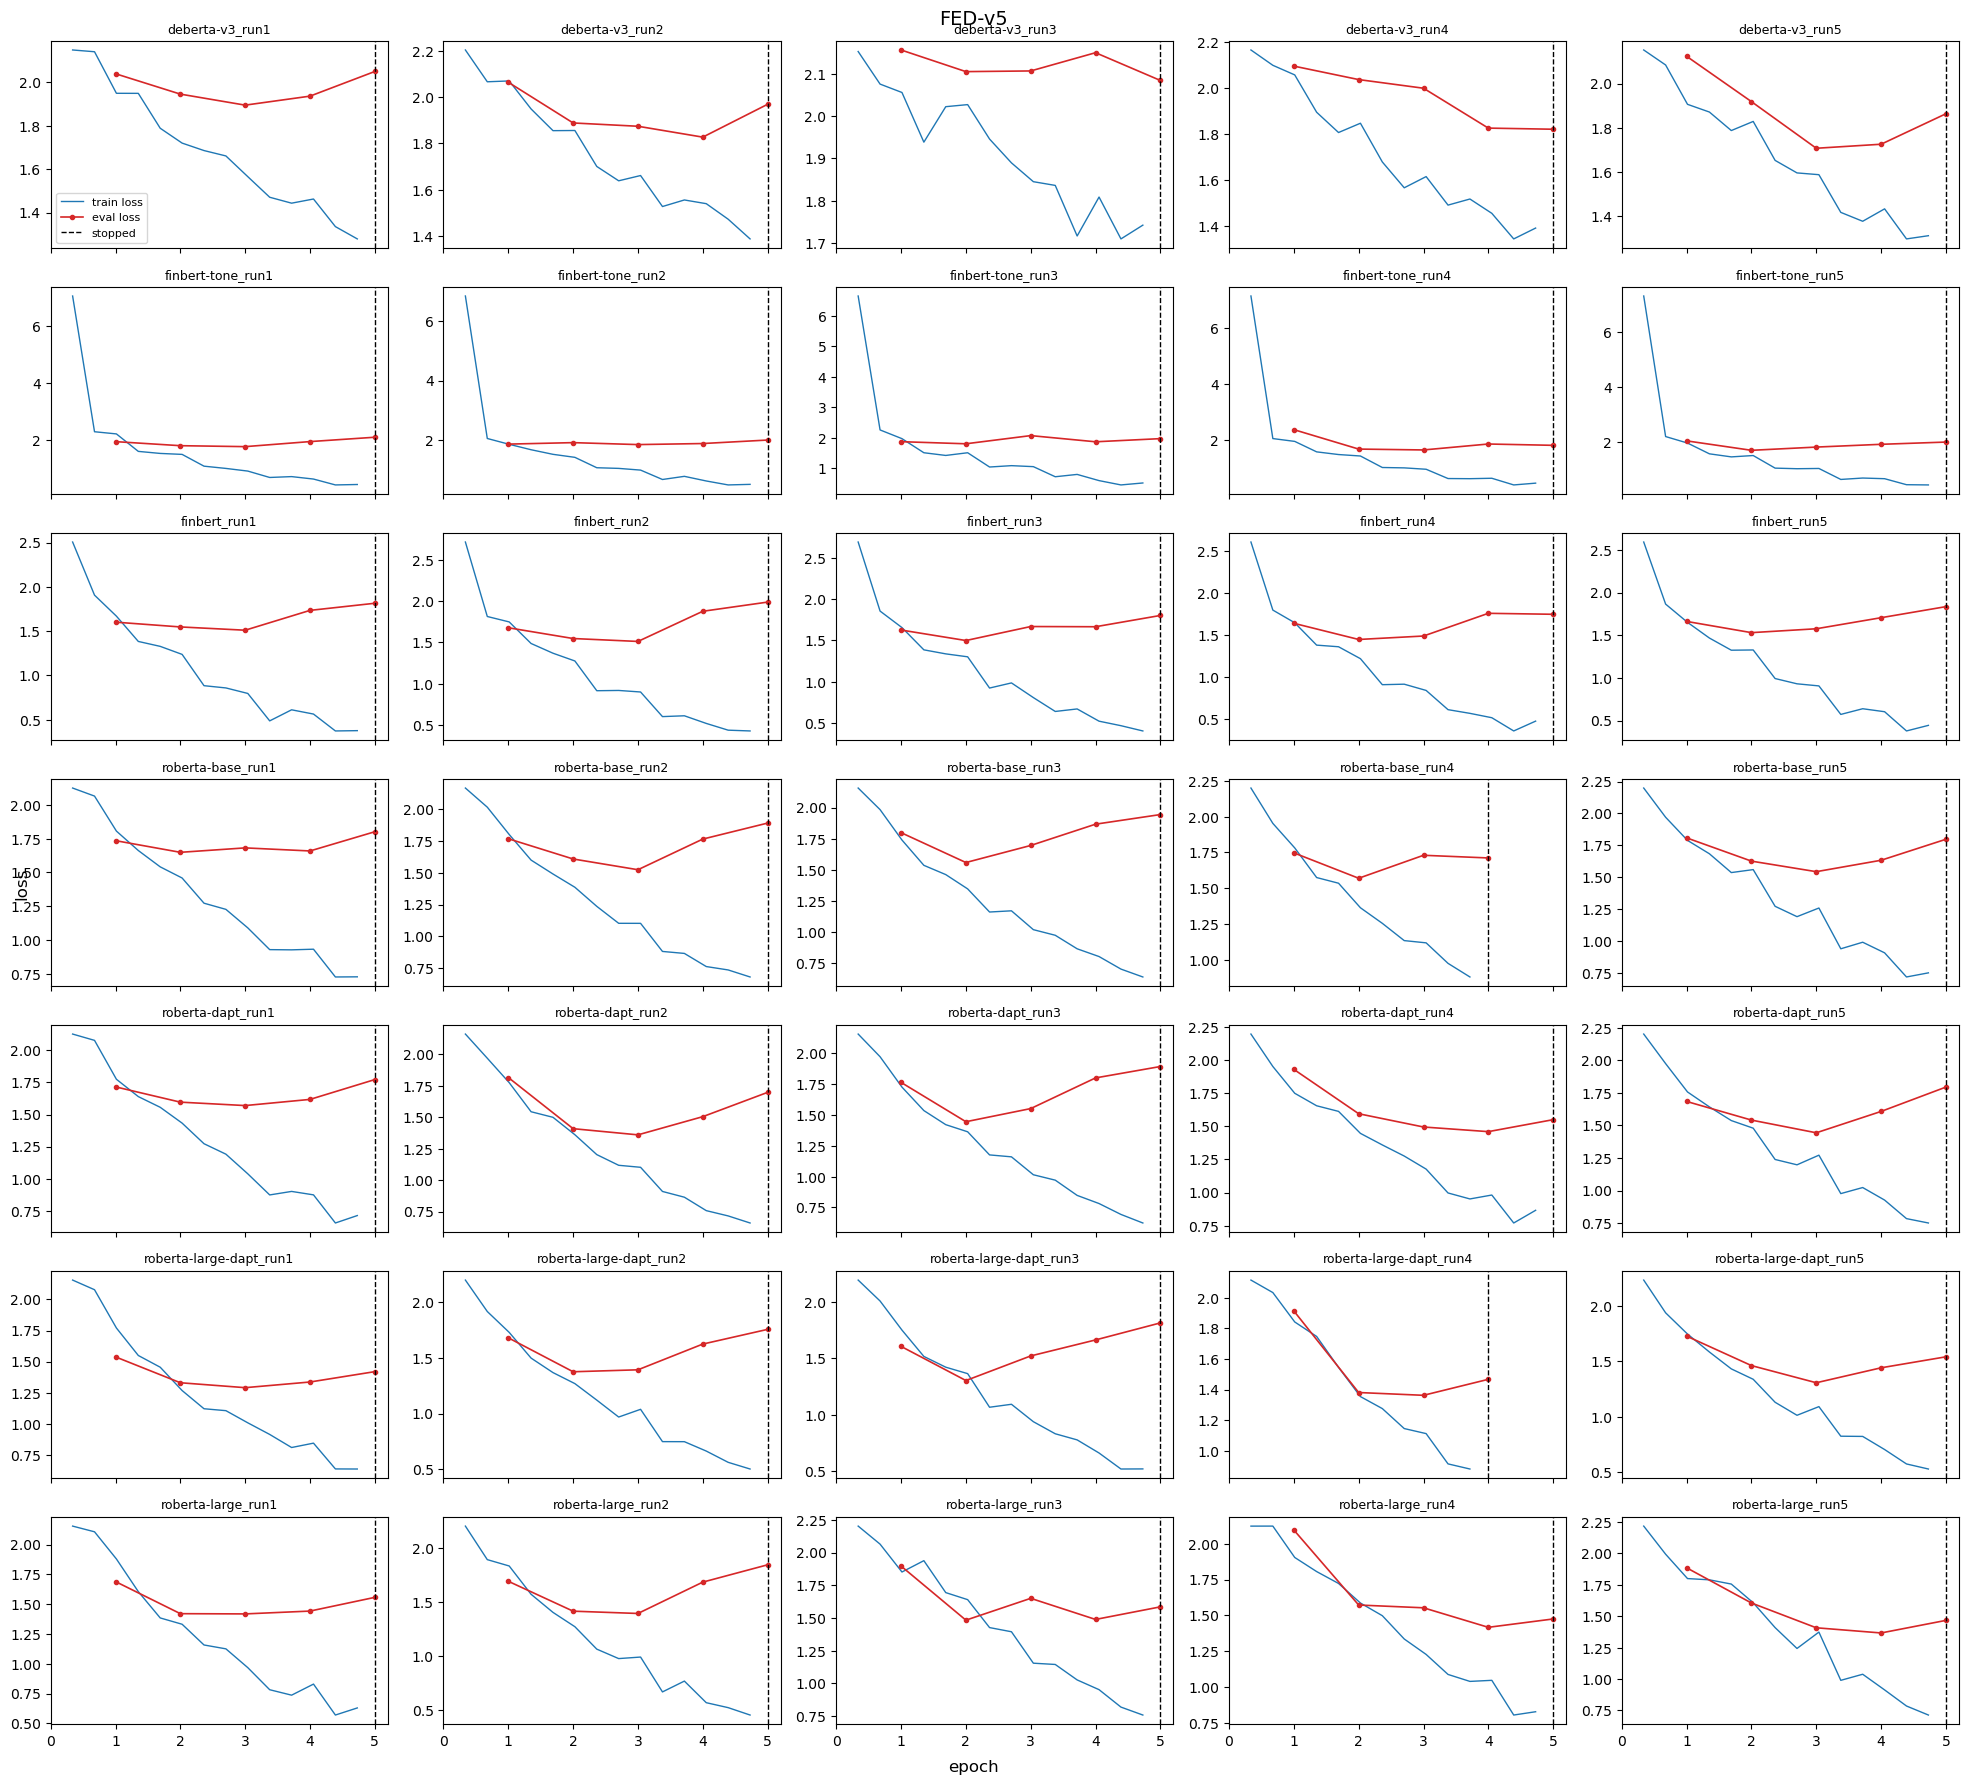

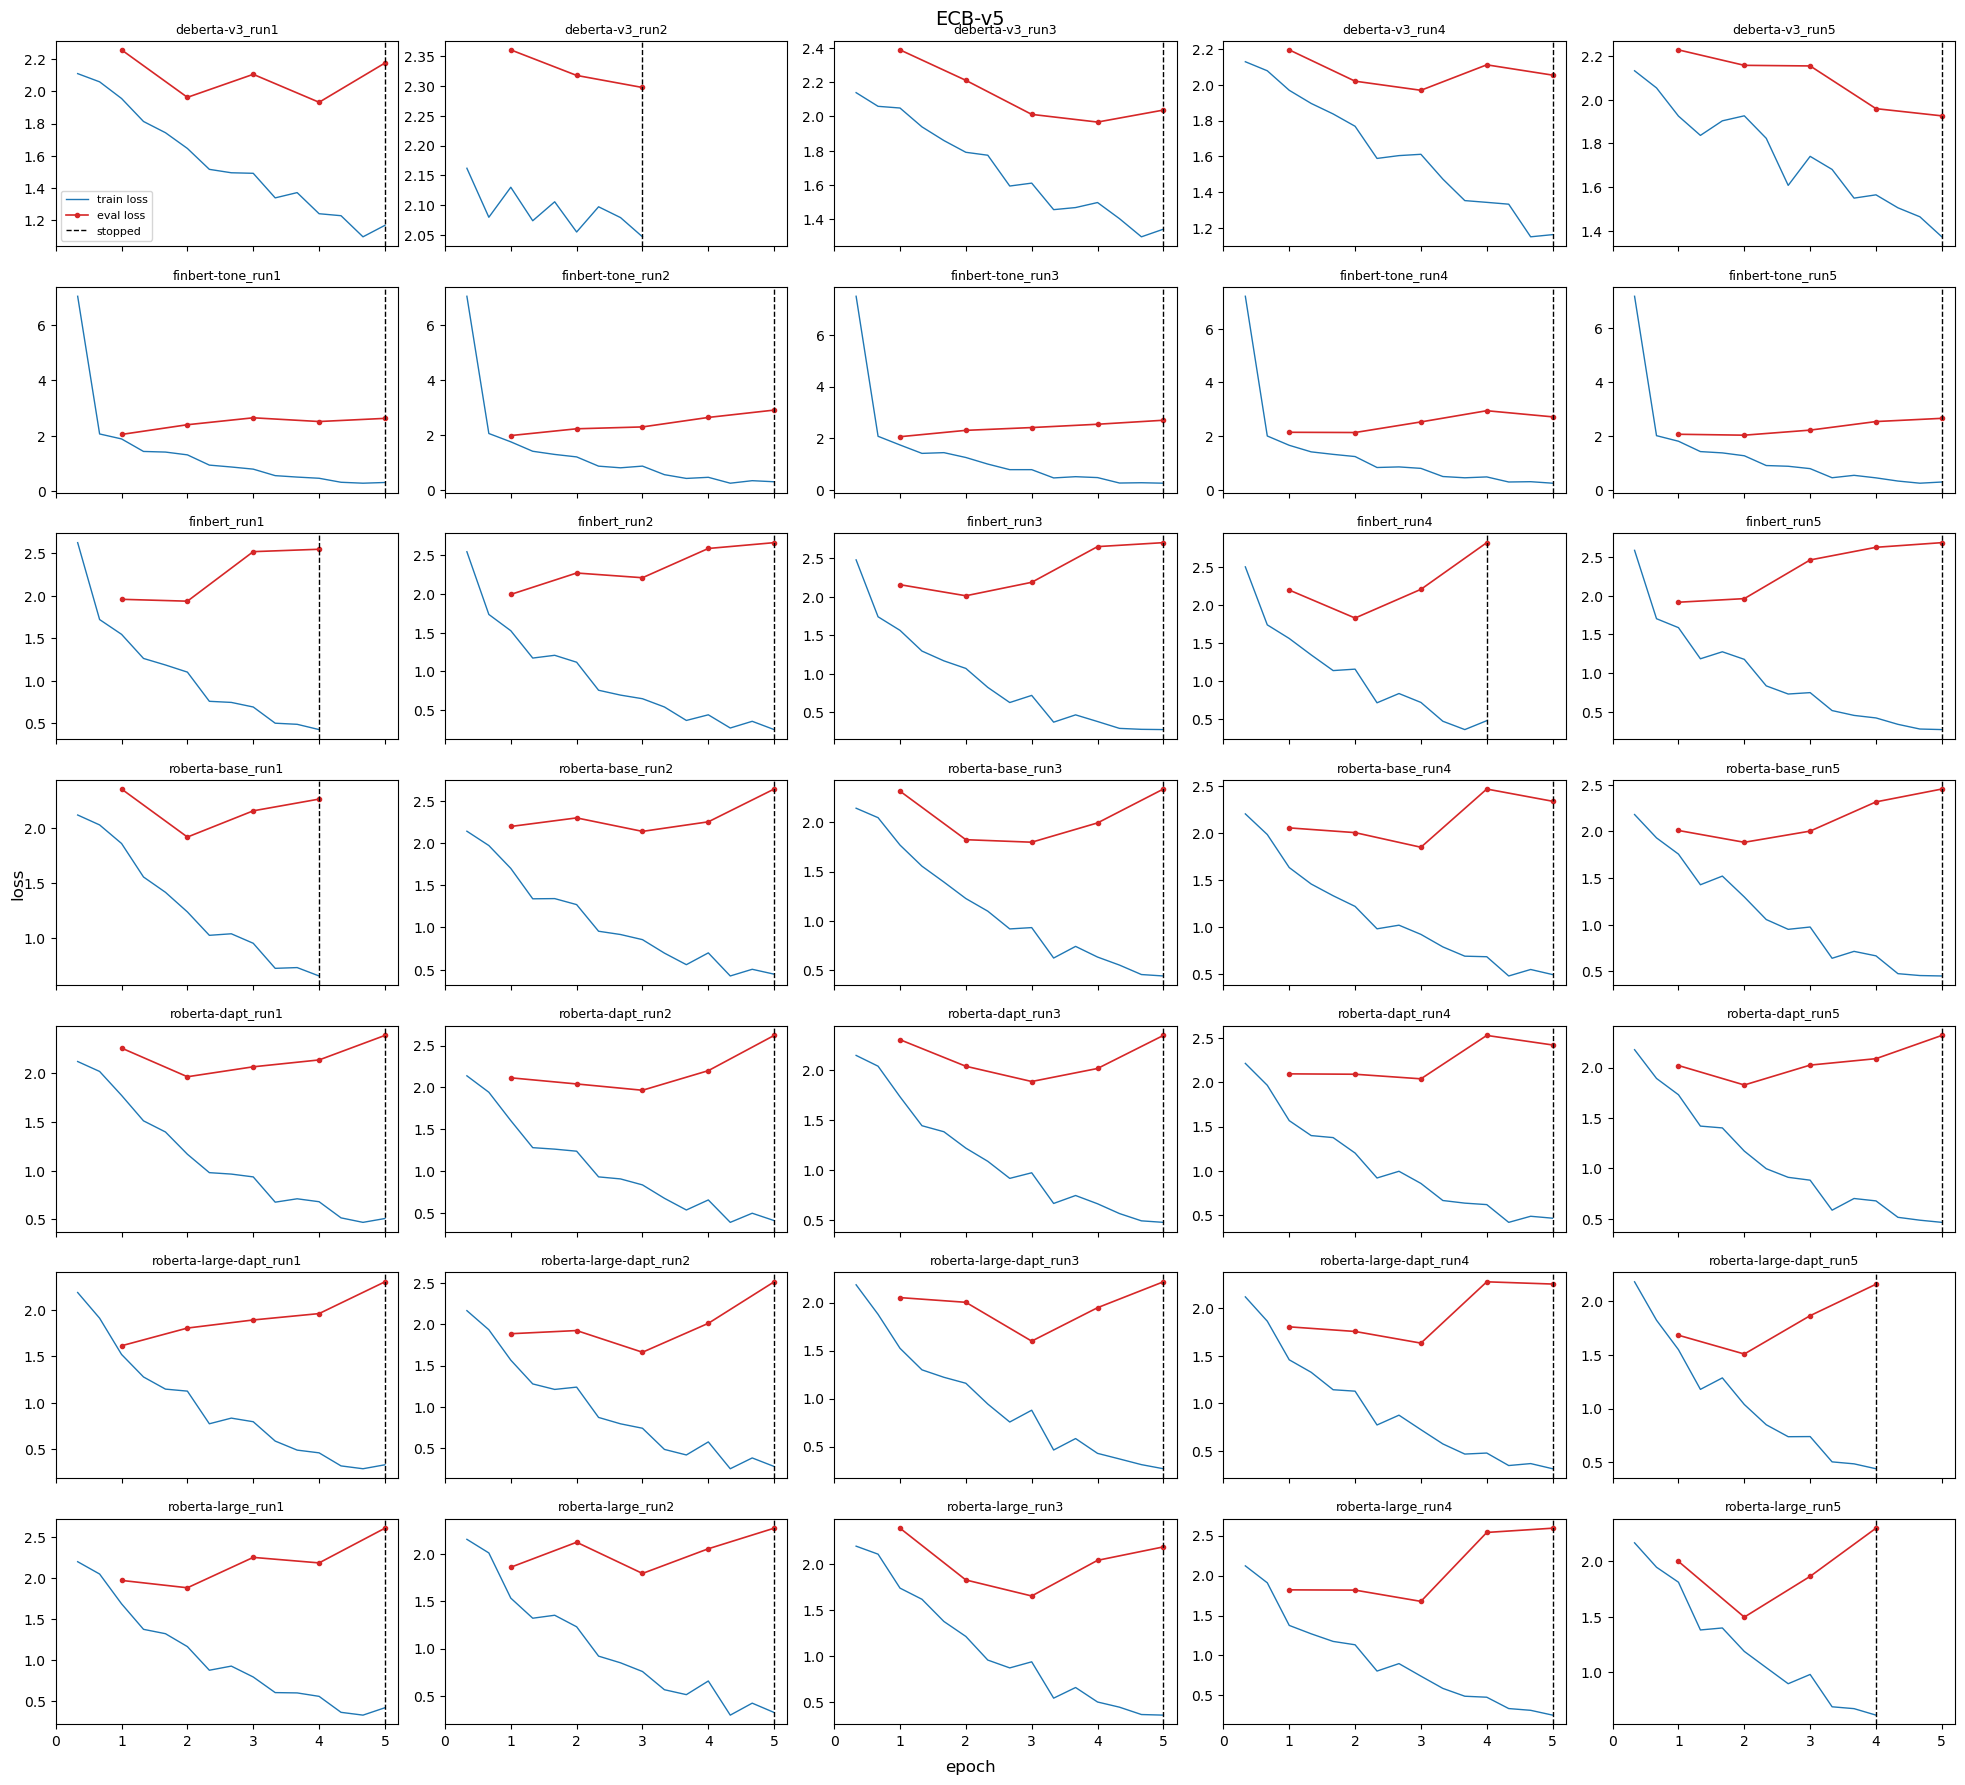

In [2]:
import json, glob
from pathlib import Path
import matplotlib.pyplot as plt

trainer_state_path_ecb = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/Bert Model Finetuning Code /Trail of Different Data Split/Learning rate - 3e-5/logs/ECB-v5/*trainer_state.json")
trainer_state_path_fed = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/Bert Model Finetuning Code /Trail of Different Data Split/Learning rate - 3e-5/logs/FED-v5/*trainer_state.json")

for inst, pattern in [("FED-v5", trainer_state_path_fed), ("ECB-v5", trainer_state_path_ecb)]:
    files = sorted(glob.glob(str(pattern)))
    ncols, nrows = 5, -(-len(files) // 5)          # 5 runs per row -> one row per model
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 2.6*nrows), sharex=True, squeeze=False)

    for ax, f in zip(axes.flat, files):
        s  = json.load(open(f))
        tr = [(e["epoch"], e["loss"])      for e in s["log_history"] if "loss" in e]
        ev = [(e["epoch"], e["eval_loss"]) for e in s["log_history"] if "eval_loss" in e]
        ax.plot(*zip(*tr), color="tab:blue", lw=1, label="train loss")
        ax.plot(*zip(*ev), "o-", color="tab:red", lw=1.2, ms=3, label="eval loss")
        ax.axvline(s["epoch"], color="black", ls="--", lw=1, label="stopped")
        ax.set_xlim(0, s.get("num_train_epochs", 5) + 0.2)
        ax.set_title(Path(f).name.replace("_trainer_state.json", ""), fontsize=9)

    for ax in axes.flat[len(files):]:
        ax.axis("off")
    axes.flat[0].legend(fontsize=8)
    fig.suptitle(inst, fontsize=14)
    fig.supxlabel("epoch"); fig.supylabel("loss")
    plt.tight_layout()
    plt.show()

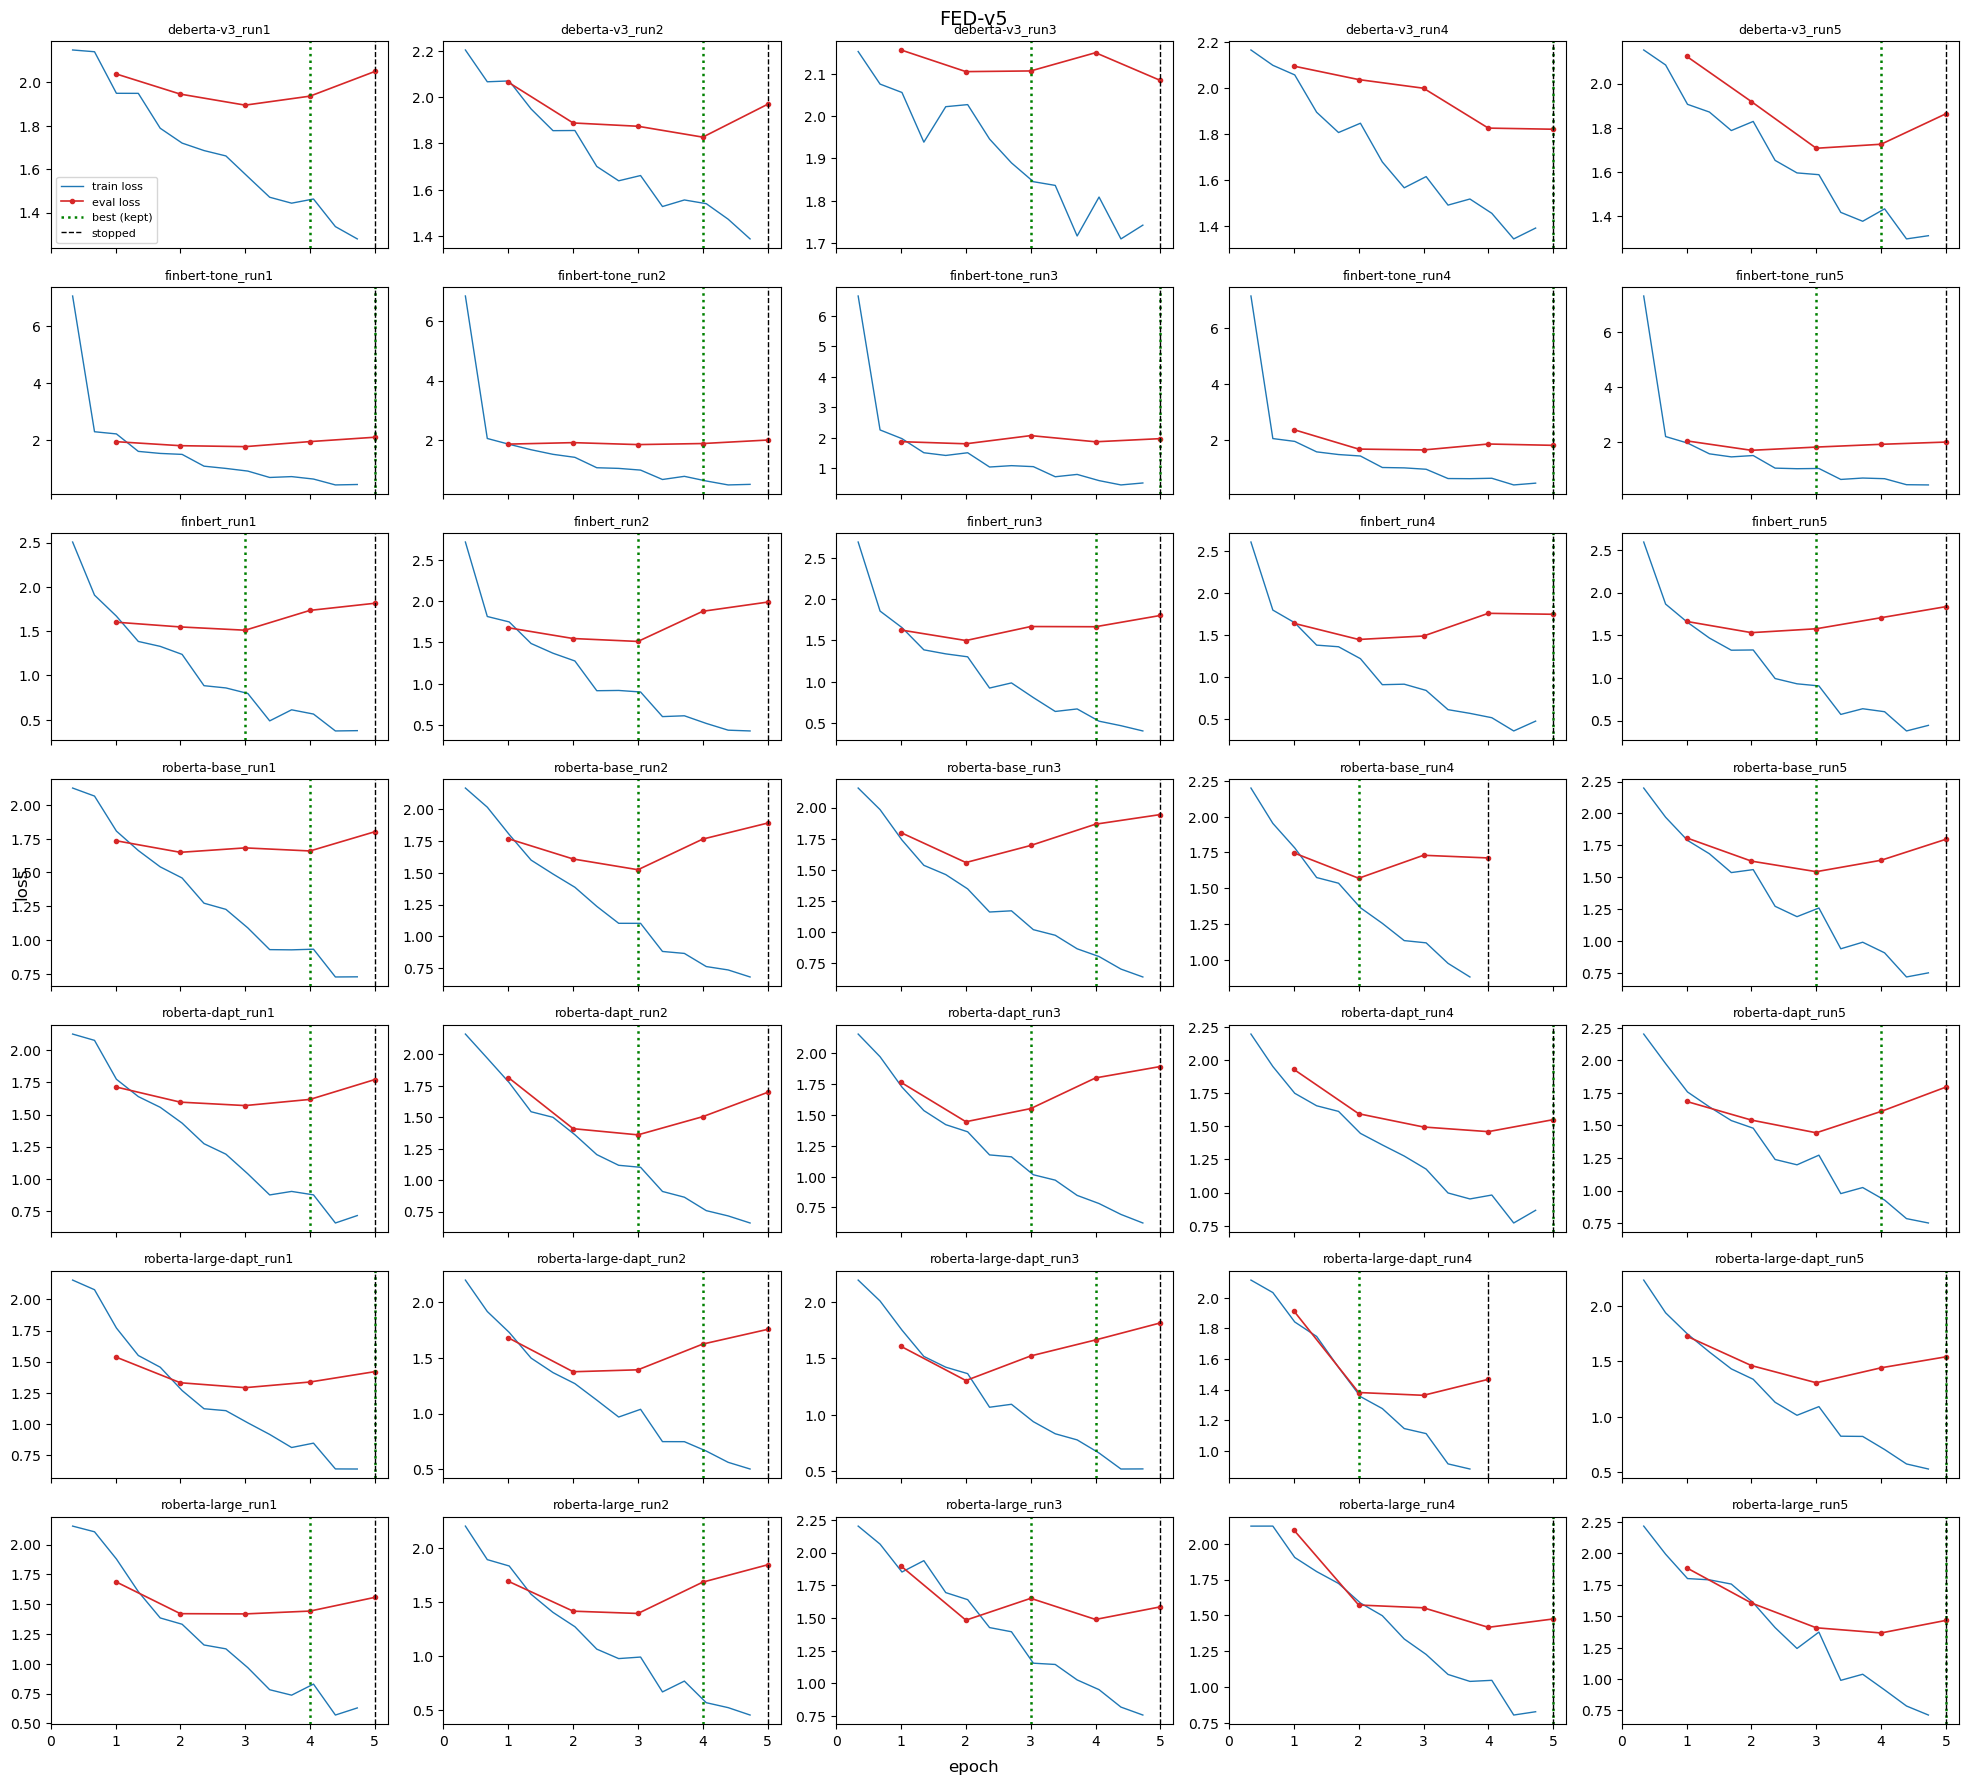

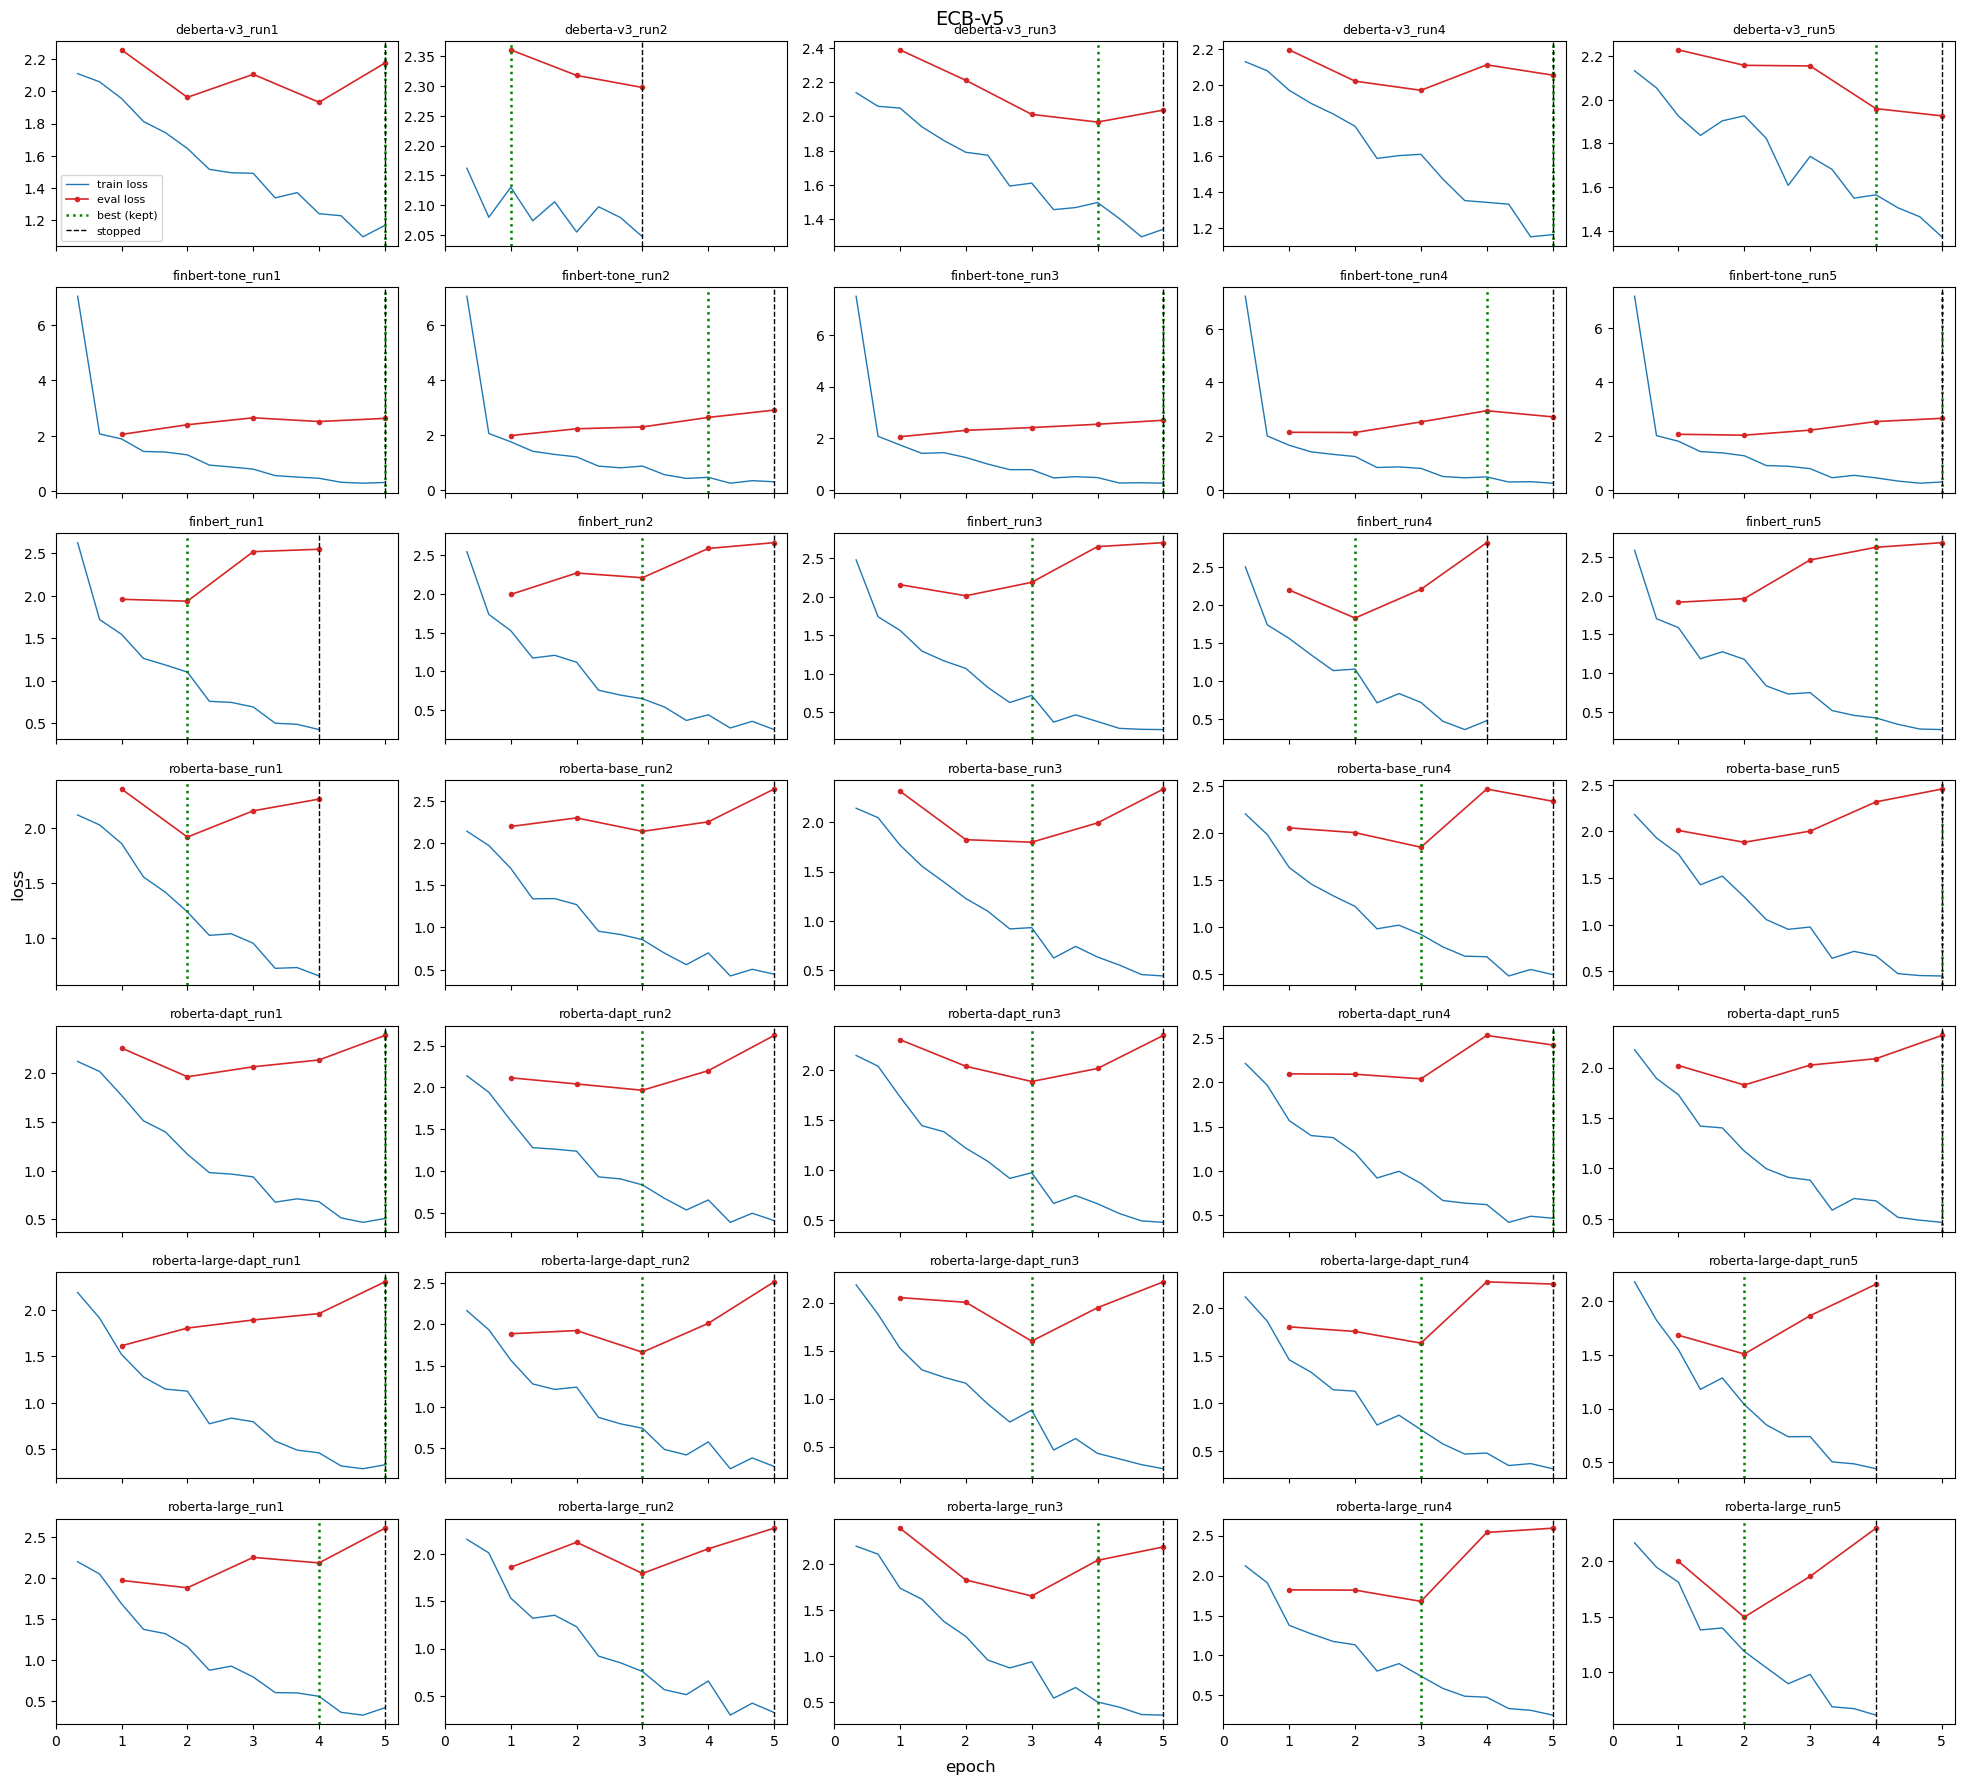

In [3]:
import json, glob, re
from pathlib import Path
import matplotlib.pyplot as plt

trainer_state_path_ecb = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/Bert Model Finetuning Code /Trail of Different Data Split/Learning rate - 3e-5/logs/ECB-v5/*trainer_state.json")
trainer_state_path_fed = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/Bert Model Finetuning Code /Trail of Different Data Split/Learning rate - 3e-5/logs/FED-v5/*trainer_state.json")

for inst, pattern in [("FED-v5", trainer_state_path_fed), ("ECB-v5", trainer_state_path_ecb)]:
    files = sorted(glob.glob(str(pattern)))
    ncols, nrows = 5, -(-len(files) // 5)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 2.6*nrows), sharex=True, squeeze=False)

    for ax, f in zip(axes.flat, files):
        s  = json.load(open(f))
        tr = [(e["epoch"], e["loss"])      for e in s["log_history"] if "loss" in e]
        ev = [(e["epoch"], e["eval_loss"]) for e in s["log_history"] if "eval_loss" in e]
        ax.plot(*zip(*tr), color="tab:blue", lw=1, label="train loss")
        ax.plot(*zip(*ev), "o-", color="tab:red", lw=1.2, ms=3, label="eval loss")

        # best checkpoint = the model that load_best_model_at_end kept and you pushed to the Hub
        bstep = s.get("best_global_step") or int(re.search(r"checkpoint-(\d+)", s["best_model_checkpoint"]).group(1))
        bep   = next(e["epoch"] for e in s["log_history"] if e.get("step") == bstep and "eval_loss" in e)
        ax.axvline(bep, color="green", ls=":", lw=1.8, label="best (kept)")

        ax.axvline(s["epoch"], color="black", ls="--", lw=1, label="stopped")
        ax.set_xlim(0, s.get("num_train_epochs", 5) + 0.2)
        ax.set_title(Path(f).name.replace("_trainer_state.json", ""), fontsize=9)

    for ax in axes.flat[len(files):]:
        ax.axis("off")
    axes.flat[0].legend(fontsize=8)
    fig.suptitle(inst, fontsize=14)
    fig.supxlabel("epoch"); fig.supylabel("loss")
    plt.tight_layout()
    plt.show()

In [ ]:
import json, glob
from pathlib import Path
import matplotlib.pyplot as plt

trainer_state_path_ecb = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/Bert Model Finetuning Code /Trail of Different Data Split/Learning rate - 3e-5/logs/ECB-v5/*trainer_state.json")
trainer_state_path_fed = Path("/Users/lorenzouberti/Desktop/BANQUE DE FRANCE /Github Repos/Project/BdF-Project/Bert Model Finetuning Code /Trail of Different Data Split/Learning rate - 3e-5/logs/FED-v5/*trainer_state.json")

for inst, pattern in [("FED-v5", trainer_state_path_fed), ("ECB-v5", trainer_state_path_ecb)]:
    files = sorted(glob.glob(str(pattern)))
    ncols, nrows = 5, -(-len(files) // 5)          # 5 runs per row -> one row per model
    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 2.6*nrows), sharex=True, squeeze=False)

    for ax, f in zip(axes.flat, files):
        s  = json.load(open(f))
        tr = [(e["epoch"], e["loss"])      for e in s["log_history"] if "loss" in e]
        ev = [(e["epoch"], e["eval_loss"]) for e in s["log_history"] if "eval_loss" in e]
        ax.plot(*zip(*tr), color="tab:blue", lw=1, label="train loss")
        ax.plot(*zip(*ev), "o-", color="tab:red", lw=1.2, ms=3, label="eval loss")
        ax.axvline(s["epoch"], color="black", ls="--", lw=1, label="stopped")
        ax.set_xlim(0, s.get("num_train_epochs", 5) + 0.2)
        ax.set_title(Path(f).name.replace("_trainer_state.json", ""), fontsize=9)

    for ax in axes.flat[len(files):]:
        ax.axis("off")
    axes.flat[0].legend(fontsize=8)
    fig.suptitle(inst, fontsize=14)
    fig.supxlabel("epoch"); fig.supylabel("loss")
    plt.tight_layout()
    plt.show()